# Notebook 12 — LSTM with Enriched Technical Indicators
**Task:** BTC/USDT hourly price direction (up/down) classification  
**Models:** LSTM from Scratch (NumPy) · LSTM PyTorch (nn.LSTM)  
**Input:** 48-feature enriched set — original 10 + RSI · MACD · Bollinger · EMA · ATR · ROC · Stochastic · OBV · Lags · Rolling stats · Time features · Interactions  
**Key difference from notebook 9:** LSTM now sees a rich multi-indicator feature vector at each timestep, giving it much more signal per step than price-derived lags alone.

In [23]:
!pip install torch --quiet

In [24]:
import os, json, pickle, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR   = os.path.join(BASE_DIR, 'data')
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
RAW_CSV    = os.path.join(BASE_DIR, 'preprocessing-May', 'btc_1h_data_2018_to_2025.csv')

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

RESULTS_CSV  = os.path.join(RESULT_DIR, 'classification_results.csv')
RESULTS_COLS = ['model','accuracy','precision','sensitivity','specificity',
                'tnr','f1','roc_auc','tp','tn','fp','fn','recall']

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('BASE_DIR:', BASE_DIR)

Device: cpu
BASE_DIR: /Users/mihiniboteju/cryptoflow


In [25]:
# ── Shared utilities ──────────────────────────────────────────────────────────

def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, int((y_true == 0).sum()), int((y_true == 1).sum())
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else 0.5
    return {
        'model':       model_name,
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'precision':   round(precision_score(y_true, y_pred, zero_division=0), 4),
        'sensitivity': round(sensitivity, 4),
        'specificity': round(specificity, 4),
        'tnr':         round(specificity, 4),
        'f1':          round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc':     round(auc, 4),
        'tp':  float(tp), 'tn': float(tn), 'fp': float(fp), 'fn': float(fn),
        'recall': round(sensitivity, 4),
    }

def save_results(metrics_list):
    new_df = pd.DataFrame(metrics_list, columns=RESULTS_COLS)
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[~existing['model'].isin(new_df['model'].tolist())]
        combined = pd.concat([existing, new_df], ignore_index=True)
    else:
        combined = new_df
    combined.to_csv(RESULTS_CSV, index=False)
    print(f'Results saved → {RESULTS_CSV}')

def plot_confusion_matrix(cm, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Down','Up']); ax.set_yticklabels(['Down','Up'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
    plt.colorbar(im, ax=ax)

def make_windows(X, y, window):
    n = len(X) - window
    X_win = np.stack([X[i:i+window] for i in range(n)], axis=0)
    y_win = y[window:]
    return X_win, y_win

print('Utilities loaded.')

Utilities loaded.


## Feature Engineering — 48-Feature Enriched Set
Identical pipeline to notebook 11. We compute all indicators on the raw OHLCV data and merge by timestamp.

In [26]:
# ── Load raw OHLCV ────────────────────────────────────────────────────────────
raw = pd.read_csv(RAW_CSV)
raw.columns = raw.columns.str.strip()
raw['open time'] = pd.to_datetime(raw['Open time'].str.strip())
raw = raw[['open time','Open','High','Low','Close','Volume']].copy()
raw.columns = ['open time','open','high','low','close','volume']
raw = raw.sort_values('open time').reset_index(drop=True)

# ── Indicator functions (same as notebook 11) ─────────────────────────────────
def rsi(close, period=14):
    delta = close.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/period, min_periods=period).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/period, min_periods=period).mean()
    return 100 - (100 / (1 + gain / (loss + 1e-9)))

def macd(close, fast=12, slow=26, signal=9):
    el = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    sig = el.ewm(span=signal, adjust=False).mean()
    return el, sig, el - sig

def bollinger_bands(close, period=20, num_std=2):
    sma = close.rolling(period).mean(); std = close.rolling(period).std()
    upper = sma + num_std*std; lower = sma - num_std*std
    return upper, lower, (close-lower)/(upper-lower+1e-9), (upper-lower)/(sma+1e-9)

def atr(high, low, close, period=14):
    pc = close.shift(1)
    tr = pd.concat([high-low, (high-pc).abs(), (low-pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, min_periods=period).mean()

def stochastic(high, low, close, k=14, d=3):
    pk = (close - low.rolling(k).min()) / (high.rolling(k).max() - low.rolling(k).min() + 1e-9) * 100
    return pk, pk.rolling(d).mean()

# ── Compute indicators ────────────────────────────────────────────────────────
df = raw.copy()
df['rsi_14']   = rsi(df['close'])
df['macd_line'], df['macd_signal'], df['macd_hist'] = macd(df['close'])
df['bb_upper'], df['bb_lower'], df['bb_pct_b'], df['bb_bw'] = bollinger_bands(df['close'])
df['ema_9']    = df['close'].ewm(span=9,  adjust=False).mean()
df['ema_21']   = df['close'].ewm(span=21, adjust=False).mean()
df['ema_cross']= df['ema_9'] - df['ema_21']
df['atr_14']   = atr(df['high'], df['low'], df['close'])
df['roc_10']   = (df['close'] - df['close'].shift(10)) / (df['close'].shift(10) + 1e-9) * 100
df['stoch_k'], df['stoch_d'] = stochastic(df['high'], df['low'], df['close'])
df['stoch_cross'] = df['stoch_k'] - df['stoch_d']
obv_dir = np.sign(df['close'].diff().fillna(0))
df['obv_raw']  = (obv_dir * df['volume']).cumsum()
df['obv_ema']  = df['obv_raw'].ewm(span=21, adjust=False).mean()
df['obv_signal_norm'] = (df['obv_raw'] - df['obv_ema']) / (df['atr_14'] * df['close'] + 1e-9)

# Lag features (1h & 2h)
for col in ['rsi_14','macd_hist','bb_pct_b','roc_10','stoch_k','ema_cross']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)

# Rolling statistics
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
for h in [6, 12, 24]:
    df[f'roll_mean_{h}h'] = df['log_ret'].rolling(h).mean()
    df[f'roll_std_{h}h']  = df['log_ret'].rolling(h).std()

# Time features (cyclical)
df['hour_sin'] = np.sin(2*np.pi*df['open time'].dt.hour / 24)
df['hour_cos'] = np.cos(2*np.pi*df['open time'].dt.hour / 24)
df['dow_sin']  = np.sin(2*np.pi*df['open time'].dt.dayofweek / 7)
df['dow_cos']  = np.cos(2*np.pi*df['open time'].dt.dayofweek / 7)

# Interaction features
df['rsi_x_macd']  = (df['rsi_14'] / 100) * df['macd_hist']
df['bb_x_roc']    = df['bb_pct_b'] * df['roc_10']
df['stoch_x_obv'] = (df['stoch_k'] / 100) * df['obv_signal_norm']

# ── Collect all new indicator column names ────────────────────────────────────
lag_cols      = [f'{c}_{l}' for c in ['rsi_14','macd_hist','bb_pct_b','roc_10','stoch_k','ema_cross']
                             for l in ['lag1','lag2']]
roll_cols     = [f'roll_{s}_{h}h' for h in [6,12,24] for s in ['mean','std']]
time_cols     = ['hour_sin','hour_cos','dow_sin','dow_cos']
interact_cols = ['rsi_x_macd','bb_x_roc','stoch_x_obv']
base_cols     = ['rsi_14','macd_line','macd_signal','macd_hist',
                 'bb_pct_b','bb_bw','ema_cross','atr_14','roc_10',
                 'stoch_k','stoch_d','stoch_cross','obv_signal_norm']
indicator_cols = base_cols + lag_cols + roll_cols + time_cols + interact_cols

print(f'Indicators ready. Groups: base={len(base_cols)}, lags={len(lag_cols)},',
      f'rolling={len(roll_cols)}, time={len(time_cols)}, interactions={len(interact_cols)}')
print(f'Total new indicator cols: {len(indicator_cols)}')

Indicators ready. Groups: base=13, lags=12, rolling=6, time=4, interactions=3
Total new indicator cols: 38


In [27]:

# ── Hyperparameters ───────────────────────────────────────────────────────────
WINDOW     = 24     # lookback timesteps
HIDDEN     = 64     # reduced: 128→64 to cut overfitting
N_LAYERS   = 1      # reduced: 2→1 layer (less capacity = better generalisation)
DROPOUT    = 0.5    # increased: 0.3→0.5
EPOCHS     = 60
PATIENCE   = 7      # stop earlier before val loss climbs too far
BATCH_SIZE = 128    # larger batches = noisier gradients = implicit regularisation
LR         = 0.001
VAL_FRAC   = 0.10

ORIG_FEATURES = [
    'close_position','return_lag_1h','log_return_1h','gk_avg_3h',
    'log_return_3h','gk_lag_1h','hl_range_pct','trade_intensity',
    'atr_lag_3h','log_return_6h'
]
TARGET = 'target_class'

# ── Load & merge ──────────────────────────────────────────────────────────────
train_raw = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_train.csv'))
test_raw  = pd.read_csv(os.path.join(DATA_DIR, 'final_training_data_classification_test.csv'))
train_raw['open time'] = pd.to_datetime(train_raw['open time'])
test_raw['open time']  = pd.to_datetime(test_raw['open time'])

indicators_df  = df[['open time'] + indicator_cols].copy()
train_merged   = train_raw.merge(indicators_df, on='open time', how='left')
test_merged    = test_raw.merge(indicators_df,  on='open time', how='left')

ALL_FEATURES = ORIG_FEATURES + indicator_cols
INPUT_DIM    = len(ALL_FEATURES)

train_merged = train_merged.dropna(subset=ALL_FEATURES).reset_index(drop=True)
test_merged  = test_merged.dropna(subset=ALL_FEATURES).reset_index(drop=True)

X_raw_train = train_merged[ALL_FEATURES].values.astype(np.float32)
y_raw_train = train_merged[TARGET].values.astype(np.int64)
X_raw_test  = test_merged[ALL_FEATURES].values.astype(np.float32)
y_raw_test  = test_merged[TARGET].values.astype(np.int64)

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_sc_train = scaler.fit_transform(X_raw_train)
X_sc_test  = scaler.transform(X_raw_test)

with open(os.path.join(MODEL_DIR, 'scaler_lstm_enriched.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# ── Sliding windows ───────────────────────────────────────────────────────────
X_win_train, y_win_train = make_windows(X_sc_train, y_raw_train, WINDOW)
X_win_test,  y_win_test  = make_windows(X_sc_test,  y_raw_test,  WINDOW)

# Temporal val split
n_val = int(len(X_win_train) * VAL_FRAC)
n_tr  = len(X_win_train) - n_val
X_tr, X_val = X_win_train[:n_tr],  X_win_train[n_tr:]
y_tr, y_val = y_win_train[:n_tr],  y_win_train[n_tr:]

print(f'Input dim  : {INPUT_DIM} features')
print(f'X_tr       : {X_tr.shape}   y_tr  : {y_tr.shape}')
print(f'X_val      : {X_val.shape}   y_val : {y_val.shape}')
print(f'X_test     : {X_win_test.shape}  y_test: {y_win_test.shape}')
print(f'\nHyperparams: hidden={HIDDEN}, layers={N_LAYERS}, dropout={DROPOUT},',
      f'batch={BATCH_SIZE}, patience={PATIENCE}')


Input dim  : 48 features
X_tr       : (54105, 24, 48)   y_tr  : (54105,)
X_val      : (6011, 24, 48)   y_val : (6011,)
X_test     : (10611, 24, 48)  y_test: (10611,)

Hyperparams: hidden=64, layers=1, dropout=0.5, batch=128, patience=7


## Model 1 — LSTM from Scratch (NumPy + Adam)
Same 4-gate implementation as notebook 9, but now receives `input_dim=48` at each timestep instead of 10.

In [28]:
class LSTMScratch:
    """
    Multivariate LSTM from scratch (NumPy).
    Gates: forget (f), input (i), cell candidate (g), output (o).
    Trained sample-by-sample with BPTT through the sequence.
    Optimiser: Adam.
    """
    def __init__(self, input_dim, hidden_dim, lr=0.001):
        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.lr         = lr
        d, h = input_dim, hidden_dim
        scale = np.sqrt(2.0 / (d + h))

        # Concatenated weight matrix for all 4 gates [i, f, g, o]
        self.Wx = np.random.randn(4*h, d) * scale
        self.Wh = np.random.randn(4*h, h) * scale
        self.b  = np.zeros(4*h)
        # Output layer
        self.Wy = np.random.randn(1, h) * scale
        self.by = np.zeros(1)

        # Adam state
        self._params = ['Wx','Wh','b','Wy','by']
        self._m = {p: np.zeros_like(getattr(self, p)) for p in self._params}
        self._v = {p: np.zeros_like(getattr(self, p)) for p in self._params}
        self._t = 0

    @staticmethod
    def _sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -30, 30)))
    @staticmethod
    def _tanh(x):    return np.tanh(np.clip(x, -30, 30))

    def _forward_sequence(self, x_seq):
        T, d = x_seq.shape
        h = self.hidden_dim
        H = np.zeros((T+1, h)); C = np.zeros((T+1, h))
        cache = []
        for t in range(T):
            gates = self.Wx @ x_seq[t] + self.Wh @ H[t] + self.b
            i = self._sigmoid(gates[0*h:1*h])
            f = self._sigmoid(gates[1*h:2*h])
            g = self._tanh(gates[2*h:3*h])
            o = self._sigmoid(gates[3*h:4*h])
            C[t+1] = f*C[t] + i*g
            H[t+1] = o * self._tanh(C[t+1])
            cache.append((x_seq[t], H[t], C[t], i, f, g, o, C[t+1], H[t+1]))
        y_logit = (self.Wy @ H[T] + self.by)[0]
        y_prob  = self._sigmoid(y_logit)
        return y_prob, H, C, cache

    def _adam_update(self, param_name, grad):
        b1, b2, eps = 0.9, 0.999, 1e-8
        self._t += 1
        self._m[param_name] = b1*self._m[param_name] + (1-b1)*grad
        self._v[param_name] = b2*self._v[param_name] + (1-b2)*grad**2
        m_hat = self._m[param_name] / (1 - b1**self._t)
        v_hat = self._v[param_name] / (1 - b2**self._t)
        setattr(self, param_name,
                getattr(self, param_name) - self.lr * m_hat / (np.sqrt(v_hat) + eps))

    def _backward(self, y_true, y_prob, H, C, cache):
        h = self.hidden_dim
        dWx = np.zeros_like(self.Wx); dWh = np.zeros_like(self.Wh)
        db  = np.zeros_like(self.b)
        dWy = np.zeros_like(self.Wy); dby = np.zeros_like(self.by)
        T   = len(cache)

        dL_dylogit = y_prob - y_true
        dWy += dL_dylogit * H[T].reshape(1, -1)
        dby += dL_dylogit
        dH_next = (self.Wy.T * dL_dylogit).flatten()
        dC_next = np.zeros(h)

        for t in reversed(range(T)):
            x_t, H_prev, C_prev, i, f, g, o, C_t, H_t = cache[t]
            tanh_Ct = self._tanh(C_t)
            dH = dH_next
            do  = dH * tanh_Ct
            dC  = dH * o * (1 - tanh_Ct**2) + dC_next
            df  = dC * C_prev
            di  = dC * g
            dg  = dC * i
            dC_next = dC * f

            # gate pre-activation gradients
            dgates = np.concatenate([
                di * i * (1-i),
                df * f * (1-f),
                dg * (1-g**2),
                do * o * (1-o)
            ])
            dWx += np.outer(dgates, x_t)
            dWh += np.outer(dgates, H_prev)
            db  += dgates
            dH_next = self.Wh.T @ dgates

        for pn, grad in [('Wx',dWx),('Wh',dWh),('b',db),('Wy',dWy),('by',dby)]:
            self._adam_update(pn, grad)

    def train_epoch(self, X_win, y_win):
        idx = np.random.permutation(len(X_win))
        total_loss = 0.0
        for i in idx:
            y_prob, H, C, cache = self._forward_sequence(X_win[i])
            y_t = float(y_win[i])
            total_loss += -(y_t*np.log(y_prob+1e-9) + (1-y_t)*np.log(1-y_prob+1e-9))
            self._backward(y_t, y_prob, H, C, cache)
        return total_loss / len(X_win)

    def predict_proba(self, X_win):
        return np.array([self._forward_sequence(x)[0] for x in X_win])

    def predict(self, X_win, threshold=0.5):
        return (self.predict_proba(X_win) >= threshold).astype(int)

print('LSTMScratch class defined  (input_dim will be set at instantiation).')

LSTMScratch class defined  (input_dim will be set at instantiation).


In [29]:
# ── Train scratch LSTM ────────────────────────────────────────────────────────
# Use a smaller hidden=64 for scratch to keep training time reasonable
SCRATCH_HIDDEN = 64
lstm_scratch = LSTMScratch(input_dim=INPUT_DIM, hidden_dim=SCRATCH_HIDDEN, lr=LR)

scratch_train_losses, scratch_val_losses = [], []
best_val_loss = np.inf
patience_counter = 0
best_scratch_state = None

print(f'Training LSTM Scratch  (input_dim={INPUT_DIM}, hidden={SCRATCH_HIDDEN})')
print(f'Epochs={EPOCHS}, patience={PATIENCE}  — training ~{len(X_tr):,} sequences')

# Subsample training for speed: use every 4th sample (still ~43K sequences)
X_tr_sub = X_tr[::4]; y_tr_sub = y_tr[::4]

for epoch in range(1, EPOCHS+1):
    train_loss = lstm_scratch.train_epoch(X_tr_sub, y_tr_sub)

    # Validate on a subsample of val for speed
    val_probs = lstm_scratch.predict_proba(X_val[::4])
    val_labels = y_val[::4]
    val_loss = -np.mean(
        val_labels * np.log(val_probs+1e-9) +
        (1-val_labels) * np.log(1-val_probs+1e-9)
    )
    scratch_train_losses.append(train_loss)
    scratch_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        best_scratch_state = {
            p: getattr(lstm_scratch, p).copy() for p in lstm_scratch._params
        }
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}.')
        break

# Restore best weights
for p, v in best_scratch_state.items():
    setattr(lstm_scratch, p, v)

print('Scratch training complete.')

Training LSTM Scratch  (input_dim=48, hidden=64)
Epochs=60, patience=7  — training ~54,105 sequences
  Epoch   1/60 | train_loss=0.6956 | val_loss=0.6968 | patience=0/7
  Epoch   5/60 | train_loss=0.6797 | val_loss=0.7036 | patience=2/7
  Epoch  10/60 | train_loss=0.5741 | val_loss=0.7817 | patience=7/7
  Early stopping at epoch 10.
Scratch training complete.



── LSTM Enriched Scratch ─────────────────────
  model          : LSTM Enriched Scratch
  accuracy       : 0.5096
  precision      : 0.5145
  sensitivity    : 0.4598
  specificity    : 0.5601
  tnr            : 0.5601
  f1             : 0.4856
  roc_auc        : 0.5124
  tp             : 2456.0
  tn             : 2951.0
  fp             : 2318.0
  fn             : 2886.0
  recall         : 0.4598


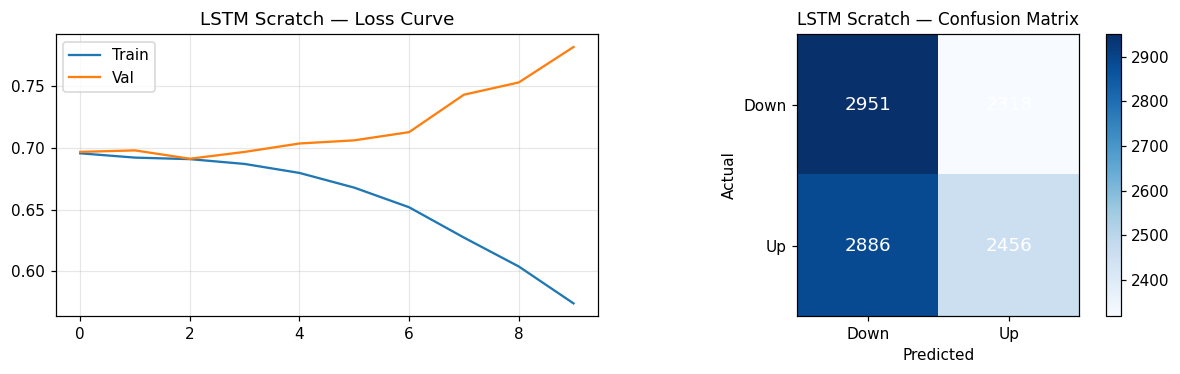

Model saved → models/lstm_enriched_scratch.pkl


In [30]:
# ── Evaluate scratch LSTM ─────────────────────────────────────────────────────
scratch_prob = lstm_scratch.predict_proba(X_win_test)
scratch_pred = lstm_scratch.predict(X_win_test)
metrics_scratch = compute_metrics('LSTM Enriched Scratch', y_win_test, scratch_pred, scratch_prob)

print('\n── LSTM Enriched Scratch ─────────────────────')
for k, v in metrics_scratch.items():
    print(f'  {k:15s}: {v}')

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(scratch_train_losses, label='Train'); axes[0].plot(scratch_val_losses, label='Val')
axes[0].set_title('LSTM Scratch — Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

cm_scratch = confusion_matrix(y_win_test, scratch_pred)
plot_confusion_matrix(cm_scratch, 'LSTM Scratch — Confusion Matrix', ax=axes[1])
plt.tight_layout(); plt.show()

# Save
import dill
with open(os.path.join(MODEL_DIR, 'lstm_enriched_scratch.pkl'), 'wb') as f:
    dill.dump(lstm_scratch, f)
print('Model saved → models/lstm_enriched_scratch.pkl')

## Model 2 — LSTM PyTorch (nn.LSTM)
2-layer stacked LSTM, hidden=128, dropout=0.3.  
Trained with mini-batches + early stopping on validation loss.

In [35]:

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_dim,
            hidden_size = hidden_dim,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)                    # (batch, seq, hidden)
        out    = self.dropout(out[:, -1, :])      # last timestep + dropout
        return torch.sigmoid(self.fc(out)).squeeze(1)


def train_pytorch_lstm(model, X_tr, y_tr, X_val, y_val,
                       epochs, patience, batch_size, lr, device):
    # weight_decay = L2 regularisation — penalises large weights directly
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCELoss()

    Xt = torch.FloatTensor(X_tr).to(device)
    yt = torch.FloatTensor(y_tr.astype(np.float32)).to(device)
    Xv = torch.FloatTensor(X_val).to(device)
    yv = torch.FloatTensor(y_val.astype(np.float32)).to(device)

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)

    train_losses, val_losses = [], []
    best_val, best_state, patience_ctr = np.inf, None, 0

    for epoch in range(1, epochs+1):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xv), yv).item()

        train_losses.append(np.mean(batch_losses))
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val     = val_loss
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{epochs} | train={train_losses[-1]:.4f} '
                  f'| val={val_loss:.4f} | patience={patience_ctr}/{patience}')

        if patience_ctr >= patience:
            print(f'  Early stopping at epoch {epoch}.')
            break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return train_losses, val_losses


print('LSTMModel class defined.')


LSTMModel class defined.


In [32]:
# ── Train PyTorch LSTM ────────────────────────────────────────────────────────
pt_model = LSTMModel(
    input_dim  = INPUT_DIM,
    hidden_dim = HIDDEN,
    n_layers   = N_LAYERS,
    dropout    = DROPOUT
).to(DEVICE)

total_params = sum(p.numel() for p in pt_model.parameters())
print(f'Model parameters: {total_params:,}')
print(f'Training PyTorch LSTM  (input_dim={INPUT_DIM}, hidden={HIDDEN}, layers={N_LAYERS}, dropout={DROPOUT})')

pt_train_losses, pt_val_losses = train_pytorch_lstm(
    pt_model, X_tr, y_tr, X_val, y_val,
    epochs=EPOCHS, patience=PATIENCE,
    batch_size=BATCH_SIZE, lr=LR, device=DEVICE
)
print('PyTorch training complete.')

Model parameters: 29,249
Training PyTorch LSTM  (input_dim=48, hidden=64, layers=1, dropout=0.5)
  Epoch   1/60 | train=0.6927 | val=0.6936 | patience=0/7
  Epoch   5/60 | train=0.6910 | val=0.6936 | patience=3/7
  Epoch  10/60 | train=0.6902 | val=0.6938 | patience=1/7
  Epoch  15/60 | train=0.6902 | val=0.6934 | patience=6/7
  Epoch  20/60 | train=0.6900 | val=0.6931 | patience=4/7
  Early stopping at epoch 23.
PyTorch training complete.



── LSTM Enriched PyTorch ─────────────────────
  model          : LSTM Enriched PyTorch
  accuracy       : 0.5174
  precision      : 0.5179
  sensitivity    : 0.5994
  specificity    : 0.4342
  tnr            : 0.4342
  f1             : 0.5557
  roc_auc        : 0.5297
  tp             : 3202.0
  tn             : 2288.0
  fp             : 2981.0
  fn             : 2140.0
  recall         : 0.5994


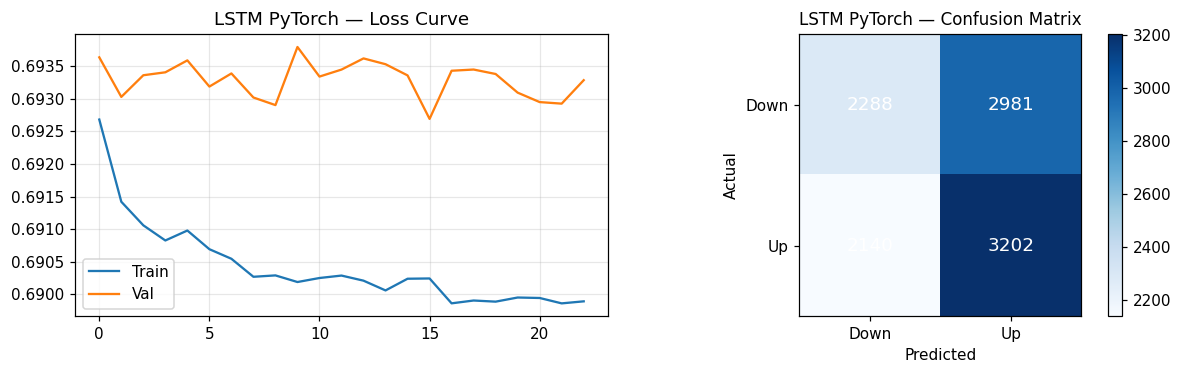

Model saved → models/lstm_enriched_pytorch.pkl


In [33]:
# ── Evaluate PyTorch LSTM ─────────────────────────────────────────────────────
pt_model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_win_test).to(DEVICE)
    pt_prob  = pt_model(X_test_t).cpu().numpy()
pt_pred = (pt_prob >= 0.5).astype(int)

metrics_pt = compute_metrics('LSTM Enriched PyTorch', y_win_test, pt_pred, pt_prob)

print('\n── LSTM Enriched PyTorch ─────────────────────')
for k, v in metrics_pt.items():
    print(f'  {k:15s}: {v}')

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(pt_train_losses, label='Train'); axes[0].plot(pt_val_losses, label='Val')
axes[0].set_title('LSTM PyTorch — Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

cm_pt = confusion_matrix(y_win_test, pt_pred)
plot_confusion_matrix(cm_pt, 'LSTM PyTorch — Confusion Matrix', ax=axes[1])
plt.tight_layout(); plt.show()

# Save
with open(os.path.join(MODEL_DIR, 'lstm_enriched_pytorch.pkl'), 'wb') as f:
    pickle.dump(pt_model.state_dict(), f)
print('Model saved → models/lstm_enriched_pytorch.pkl')

## Results — ROC Curves, Metrics Table & CSV Export

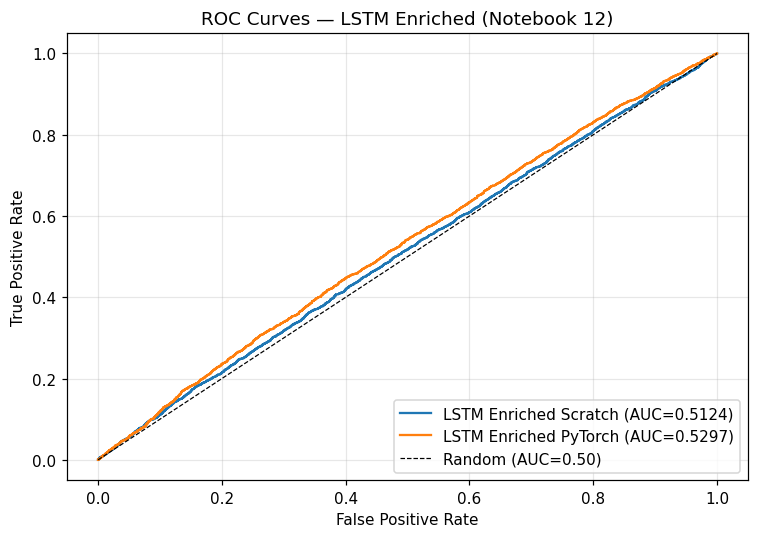

Results saved → /Users/mihiniboteju/cryptoflow/results/classification_results.csv

── Notebook 12 Summary ─────────────────────────────────────
                model  accuracy  precision  sensitivity  specificity     f1  roc_auc
LSTM Enriched Scratch    0.5096     0.5145       0.4598       0.5601 0.4856   0.5124
LSTM Enriched PyTorch    0.5174     0.5179       0.5994       0.4342 0.5557   0.5297

── All Models ──────────────────────────────────────────────
                                  model  accuracy  precision  sensitivity  specificity       f1  roc_auc
                Majority Class Baseline  0.503400   0.503400       1.0000       0.0000 0.669700 0.500000
          Logistic Regression (Scratch)  0.523600   0.526500       0.5334       0.5137 0.530000 0.538800
          Logistic Regression (sklearn)  0.524700   0.527500       0.5347       0.5145 0.531100 0.538600
                Decision Tree (Scratch)  0.529600   0.532700       0.5334       0.5257 0.533100 0.529500
        Decisi

In [34]:
# ── ROC comparison ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for label, y_prob in [
    ('LSTM Enriched Scratch',  scratch_prob),
    ('LSTM Enriched PyTorch',  pt_prob),
]:
    fpr, tpr, _ = roc_curve(y_win_test, y_prob)
    auc_val = roc_auc_score(y_win_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — LSTM Enriched (Notebook 12)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Save to CSV ───────────────────────────────────────────────────────────────
all_metrics = [metrics_scratch, metrics_pt]
save_results(all_metrics)

# ── Summary table ─────────────────────────────────────────────────────────────
display_cols = ['model','accuracy','precision','sensitivity','specificity','f1','roc_auc']
summary_df   = pd.DataFrame(all_metrics, columns=RESULTS_COLS)
print('\n── Notebook 12 Summary ─────────────────────────────────────')
print(summary_df[display_cols].to_string(index=False))

print('\n── All Models ──────────────────────────────────────────────')
all_results = pd.read_csv(RESULTS_CSV)
print(all_results[display_cols].to_string(index=False))